## 1️⃣ Conexión a BigQuery y carga de datos
Cargamos la vista maestra construida en la Fase 1 (2.163 ofertas, 26 columnas) e instalamos kaleido para que los gráficos de Plotly se guarden como imágenes fijas.

In [1]:
from google.colab import auth
auth.authenticate_user()

from google.cloud import bigquery

PROJECT_ID = "tfm-mercado-laboral-datos"
client = bigquery.Client(project=PROJECT_ID)

query = """
SELECT *
FROM `tfm-mercado-laboral-datos.mercado_laboral_datos.vista_maestra_mercado_laboral`
"""
df = client.query(query).to_dataframe()

print(df.shape)
df.head()

(4326, 26)


,job_id,title,categoria_rol,description,skills_desc,formatted_work_type,formatted_experience_level,remote_allowed,location,views,...,employee_count,follower_count,skills_lista,industrias_lista,beneficios_lista,min_salary,med_salary,max_salary,pay_period,currency
0,3245063922,Data Architect,Data Architect,Request: Data ArchitectLocation: San Francisco...,None,Contract,None,NaN,"San Francisco, CA",7.0,...,304,125864,"Engineering, Information Technology",IT Services and IT Consulting,None,NaN,NaN,NaN,None,None
1,3742692445,Sr Data Engineer with Kafka,Data Engineer,Data Engineer with Kafka (W2 Only)💯% Remote\nM...,None,Full-time,None,1.0,"Austin, TX",39.0,...,3,51,None,IT Services and IT Consulting,None,NaN,NaN,NaN,None,None
2,3780415828,Technical Business Analyst,Business Analyst,We’re actively seeking a Technical Business An...,None,Contract,None,NaN,"Albany, NY",4.0,...,43,807,"Business Development, Sales",Financial Services,None,60000.0,NaN,80000.0,YEARLY,USD
3,3797449314,Cloud Platform/ Big Data Engineer,Data Engineer,About Subaru Research and Development:Do you c...,None,Full-time,Entry level,NaN,"Michigan, United States",7.0,...,76,1093,Engineering,"Motor Vehicle Manufacturing, IT Services and I...","Medical insurance, Vision insurance, Dental in...",NaN,NaN,NaN,None,None
4,3800272386,Data Science Software Engineer,Data Scientist,Company Overview Sovrinti is a full-service en...,None,Full-time,None,1.0,United States,125.0,...,2,39,None,IT Services and IT Consulting,"Vision insurance, Medical insurance, Dental in...",NaN,NaN,NaN,None,None


In [2]:
!pip install -q kaleido==0.2.1
import plotly.io as pio
pio.renderers.default = "png"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.9/79.9 MB 11.0 MB/s eta 0:00:00


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4326 entries, 0 to 4325
Data columns (total 26 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   job_id                      4326 non-null   Int64  
 1   title                       4326 non-null   object 
 2   categoria_rol               4326 non-null   object 
 3   description                 4326 non-null   object 
 4   skills_desc                 50 non-null     object 
 5   formatted_work_type         4326 non-null   object 
 6   formatted_experience_level  3064 non-null   object 
 7   remote_allowed              1286 non-null   float64
 8   location                    4326 non-null   object 
 9   views                       4260 non-null   float64
 10  applies                     2392 non-null   float64
 11  fecha_publicacion           4326 non-null   dbdate 
 12  empresa                     4282 non-null   object 
 13  company_size                4116 

## 2️⃣ Limpieza y preparación de datos
Tratamos tres incidencias reales del dataset: la modalidad remota (que solo marca "sí", nunca "no"), los nulos de nivel de experiencia, y los outliers de salario tras normalizarlo a base anual.

In [4]:
df['remote_allowed'].value_counts(dropna=False)

,count
remote_allowed,
NaN,3040
1.0,1286


In [5]:
df['modalidad_remoto'] = df['remote_allowed'].map({1.0: 'Remoto'}).fillna('No especificado')
df['modalidad_remoto'].value_counts()

,count
modalidad_remoto,
No especificado,3040
Remoto,1286


In [6]:
df['formatted_experience_level'].value_counts(dropna=False)

,count
formatted_experience_level,
Mid-Senior level,2080
None,1262
Entry level,550
Associate,302
Director,64
Internship,54
Executive,14


In [7]:
df['formatted_experience_level'] = df['formatted_experience_level'].fillna('No especificado')
df['formatted_experience_level'].value_counts()

,count
formatted_experience_level,
Mid-Senior level,2080
No especificado,1262
Entry level,550
Associate,302
Director,64
Internship,54
Executive,14


In [8]:
df['pay_period'].value_counts(dropna=False)

,count
pay_period,
None,2996
YEARLY,914
HOURLY,406
MONTHLY,10


In [9]:
    factor_anual = {'YEARLY': 1, 'MONTHLY': 12, 'HOURLY': 2080}
df['factor_anual'] = df['pay_period'].map(factor_anual)

df['salario_min_anual'] = df['min_salary'] * df['factor_anual']
df['salario_max_anual'] = df['max_salary'] * df['factor_anual']

df[['pay_period', 'min_salary', 'factor_anual', 'salario_min_anual']].dropna().head(10)

,pay_period,min_salary,factor_anual,salario_min_anual
2,YEARLY,60000.0,1.0,60000.0
7,HOURLY,101.0,2080.0,210080.0
9,YEARLY,150000.0,1.0,150000.0
13,YEARLY,95000.0,1.0,95000.0
24,YEARLY,60000.0,1.0,60000.0
27,YEARLY,61261.0,1.0,61261.0
30,YEARLY,100000.0,1.0,100000.0
32,YEARLY,88854.0,1.0,88854.0
42,YEARLY,77265.0,1.0,77265.0
43,HOURLY,35.0,2080.0,72800.0


In [10]:
df[['salario_min_anual', 'salario_max_anual']].describe()

,salario_min_anual,salario_max_anual
count,1244.000000,1.244000e+03
mean,113876.646158,1.775830e+05
std,42853.770921,5.456024e+05
min,30.000000,3.500000e+01
25%,83200.000000,1.144000e+05
50%,110000.000000,1.456000e+05
75%,140000.000000,1.872000e+05
max,400000.000000,1.366560e+07


In [11]:
df[(df['salario_min_anual'] < 1000) | (df['salario_max_anual'] > 500000)][
    ['title', 'pay_period', 'min_salary', 'max_salary', 'salario_min_anual', 'salario_max_anual']
]

,title,pay_period,min_salary,max_salary,salario_min_anual,salario_max_anual
142,Java-Big Data Architect,YEARLY,75.0,85.0,75.0,85.0
215,"ML Engineer L5, LLM Application Frameworks, Ma...",YEARLY,100000.0,720000.0,100000.0,720000.0
279,Vice President of Data Engineering,YEARLY,400000.0,600000.0,400000.0,600000.0
542,Information Technology Business Analyst,YEARLY,60.0,65.0,60.0,65.0
645,Data Engineer,HOURLY,65.0,6570.0,135200.0,13665600.0
662,Business Analyst 24-02965,YEARLY,30.0,35.0,30.0,35.0
873,Sr. Data Engineer,YEARLY,70.0,80.0,70.0,80.0
1091,Data Architect,YEARLY,70.0,75.0,70.0,75.0
1444,Full Time - Financial Business Analyst with Re...,YEARLY,50.0,55.0,50.0,55.0
1611,Finance Senior Oracle Fusion Business Analyst,YEARLY,150.0,150.0,150.0,150.0


In [12]:
df.loc[(df['salario_min_anual'] < 1000) | (df['salario_min_anual'] > 1000000), 'salario_min_anual'] = None
df.loc[(df['salario_max_anual'] < 1000) | (df['salario_max_anual'] > 1000000), 'salario_max_anual'] = None

df[['salario_min_anual', 'salario_max_anual']].describe()

,salario_min_anual,salario_max_anual
count,1228.000000,1226.000000
mean,115359.485195,157896.340538
std,41101.044592,65066.434125
min,37315.200000,47840.000000
25%,84300.000000,114400.000000
50%,110000.000000,145600.000000
75%,141440.000000,187200.000000
max,400000.000000,720000.000000


## 3️⃣ Distribución de roles y experiencia
Vemos qué categorías de rol concentran más ofertas, y cómo se reparte el nivel de experiencia dentro de cada una.

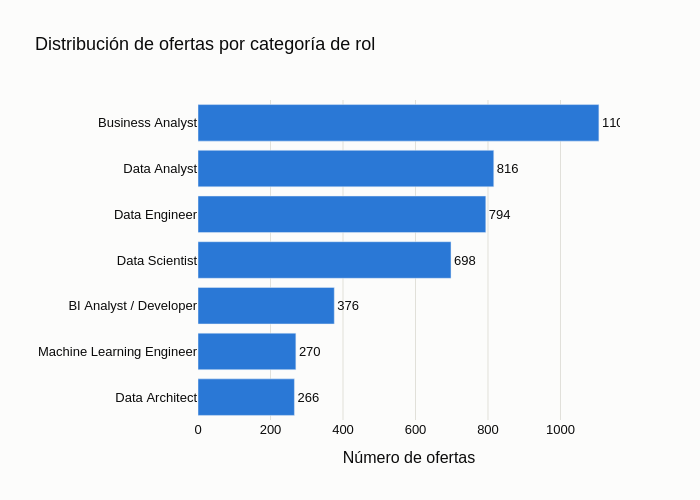

In [13]:
import plotly.express as px

conteo_roles = df['categoria_rol'].value_counts().reset_index()
conteo_roles.columns = ['categoria_rol', 'num_ofertas']

fig = px.bar(
    conteo_roles.sort_values('num_ofertas'),
    x='num_ofertas',
    y='categoria_rol',
    orientation='h',
    text='num_ofertas',
    title='Distribución de ofertas por categoría de rol'
)

fig.update_traces(marker_color='#2a78d6', textposition='outside')
fig.update_layout(
    plot_bgcolor='#fcfcfb',
    paper_bgcolor='#fcfcfb',
    xaxis_title='Número de ofertas',
    yaxis_title='',
    font=dict(color='#0b0b0b', size=13),
)
fig.update_xaxes(gridcolor='#e1e0d9', zeroline=False)
fig.update_yaxes(showgrid=False)
fig.update_layout(margin=dict(l=180))
fig.show()

In [14]:
import pandas as pd

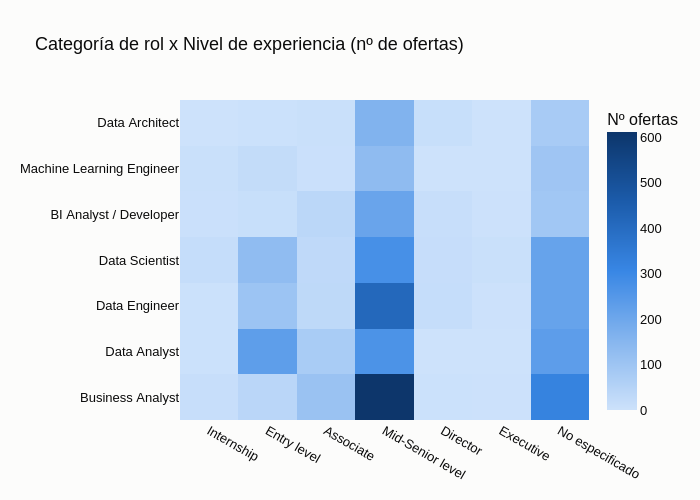

In [15]:
orden_experiencia = ['Internship', 'Entry level', 'Associate', 'Mid-Senior level', 'Director', 'Executive', 'No especificado']
orden_roles = conteo_roles.sort_values('num_ofertas', ascending=False)['categoria_rol'].tolist()

tabla_cruzada = pd.crosstab(df['categoria_rol'], df['formatted_experience_level'])
tabla_cruzada = tabla_cruzada.reindex(index=orden_roles, columns=orden_experiencia)

import plotly.graph_objects as go

colorscale_azul = [
    [0.0, '#cde2fb'],
    [0.25, '#86b6ef'],
    [0.5, '#3987e5'],
    [0.75, '#1c5cab'],
    [1.0, '#0d366b'],
]

fig = go.Figure(data=go.Heatmap(
    z=tabla_cruzada.values,
    x=tabla_cruzada.columns,
    y=tabla_cruzada.index,
    colorscale=colorscale_azul,
    colorbar=dict(title='Nº ofertas'),
    hovertemplate='%{y} - %{x}: %{z} ofertas<extra></extra>',
))

fig.update_layout(
    title='Categoría de rol x Nivel de experiencia (nº de ofertas)',
    plot_bgcolor='#fcfcfb',
    paper_bgcolor='#fcfcfb',
    font=dict(color='#0b0b0b', size=13),
    margin=dict(l=180),
)
fig.show()

## 4️⃣ Evolución temporal de las publicaciones
Analizamos cómo se reparten las ofertas día a día dentro de la ventana real de publicación del dataset, rellenando las fechas sin ninguna oferta registrada.

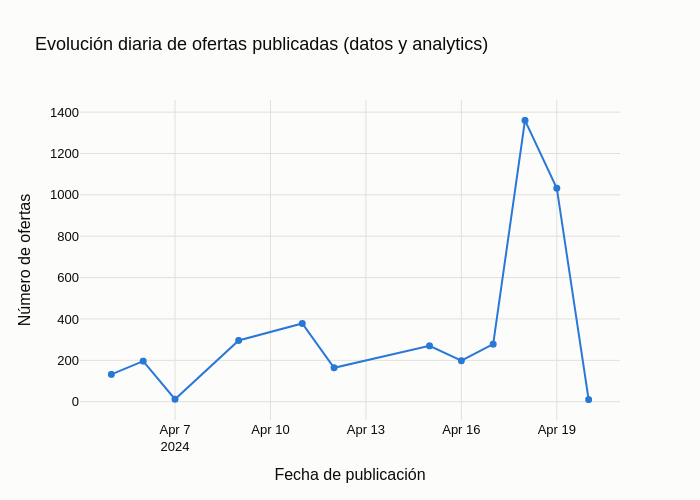

In [16]:
evolucion = df.groupby('fecha_publicacion').size().reset_index(name='num_ofertas')
evolucion = evolucion.sort_values('fecha_publicacion')

fig = px.line(
    evolucion,
    x='fecha_publicacion',
    y='num_ofertas',
    title='Evolución diaria de ofertas publicadas (datos y analytics)',
    markers=True,
)

fig.update_traces(line_color='#2a78d6', marker=dict(color='#2a78d6', size=7))
fig.update_layout(
    plot_bgcolor='#fcfcfb',
    paper_bgcolor='#fcfcfb',
    xaxis_title='Fecha de publicación',
    yaxis_title='Número de ofertas',
    font=dict(color='#0b0b0b', size=13),
)
fig.update_xaxes(gridcolor='#e1e0d9', zeroline=False)
fig.update_yaxes(gridcolor='#e1e0d9', zeroline=False)
fig.show()

In [17]:
evolucion['dia_semana'] = evolucion['fecha_publicacion'].apply(lambda f: f.strftime('%A'))
evolucion

,fecha_publicacion,num_ofertas,dia_semana
0,2024-04-05,132,Friday
1,2024-04-06,196,Saturday
2,2024-04-07,12,Sunday
3,2024-04-09,296,Tuesday
4,2024-04-11,378,Thursday
5,2024-04-12,164,Friday
6,2024-04-15,270,Monday
7,2024-04-16,198,Tuesday
8,2024-04-17,278,Wednesday
9,2024-04-18,1360,Thursday


In [18]:
evolucion['fecha_publicacion'] = pd.to_datetime(evolucion['fecha_publicacion'])
evolucion_num = evolucion[['fecha_publicacion', 'num_ofertas']]

rango_completo = pd.date_range(start='2024-04-05', end='2024-04-20', freq='D')
evolucion_completa = evolucion_num.set_index('fecha_publicacion').reindex(rango_completo, fill_value=0)
evolucion_completa.index.name = 'fecha_publicacion'
evolucion_completa = evolucion_completa.reset_index()
evolucion_completa['dia_semana'] = evolucion_completa['fecha_publicacion'].dt.strftime('%A')

evolucion_completa

,fecha_publicacion,num_ofertas,dia_semana
0,2024-04-05,132,Friday
1,2024-04-06,196,Saturday
2,2024-04-07,12,Sunday
3,2024-04-08,0,Monday
4,2024-04-09,296,Tuesday
5,2024-04-10,0,Wednesday
6,2024-04-11,378,Thursday
7,2024-04-12,164,Friday
8,2024-04-13,0,Saturday
9,2024-04-14,0,Sunday


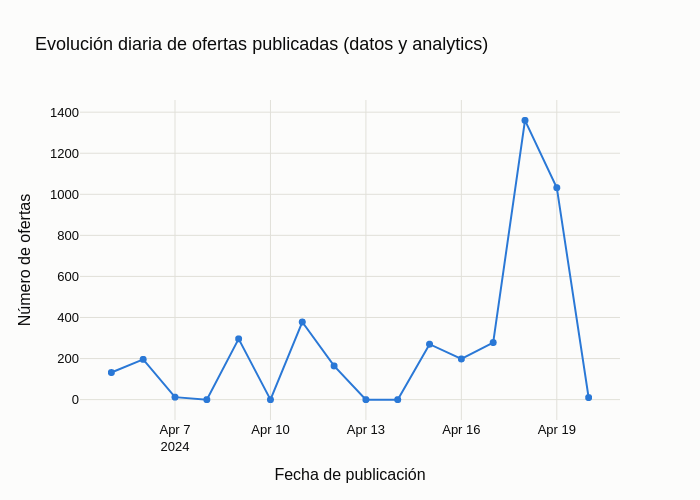

In [19]:
fig = px.line(
    evolucion_completa,
    x='fecha_publicacion',
    y='num_ofertas',
    title='Evolución diaria de ofertas publicadas (datos y analytics)',
    markers=True,
)

fig.update_traces(line_color='#2a78d6', marker=dict(color='#2a78d6', size=7))
fig.update_layout(
    plot_bgcolor='#fcfcfb',
    paper_bgcolor='#fcfcfb',
    xaxis_title='Fecha de publicación',
    yaxis_title='Número de ofertas',
    font=dict(color='#0b0b0b', size=13),
)
fig.update_xaxes(gridcolor='#e1e0d9', zeroline=False)
fig.update_yaxes(gridcolor='#e1e0d9', zeroline=False)
fig.show()

## 5️⃣ Modalidad remota por rol
Comparamos qué porcentaje de ofertas remotas tiene cada categoría de rol.

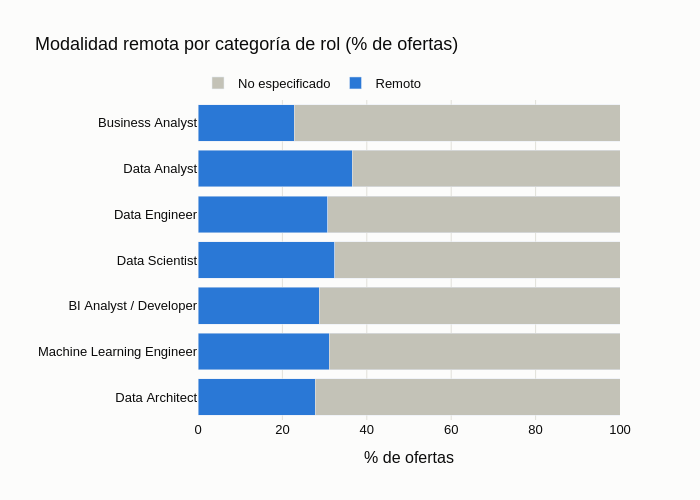

In [20]:
tabla_remoto = pd.crosstab(df['categoria_rol'], df['modalidad_remoto'], normalize='index') * 100
tabla_remoto = tabla_remoto.reindex(index=orden_roles[::-1])
tabla_remoto = tabla_remoto[['Remoto', 'No especificado']]

fig = go.Figure()
fig.add_bar(
    y=tabla_remoto.index,
    x=tabla_remoto['Remoto'],
    name='Remoto',
    orientation='h',
    marker_color='#2a78d6',
)
fig.add_bar(
    y=tabla_remoto.index,
    x=tabla_remoto['No especificado'],
    name='No especificado',
    orientation='h',
    marker_color='#c3c2b7',
)

fig.update_layout(
    barmode='stack',
    title='Modalidad remota por categoría de rol (% de ofertas)',
    plot_bgcolor='#fcfcfb',
    paper_bgcolor='#fcfcfb',
    xaxis_title='% de ofertas',
    yaxis_title='',
    font=dict(color='#0b0b0b', size=13),
    margin=dict(l=180),
    legend=dict(orientation='h', y=1.1),
)
fig.update_xaxes(gridcolor='#e1e0d9', zeroline=False, range=[0, 100])
fig.update_yaxes(showgrid=False)
fig.show()

## 6️⃣ Distribución salarial por rol
Vemos cómo se reparte el salario anual estimado dentro de cada categoría de rol.

In [21]:
df.groupby('categoria_rol')['salario_min_anual'].count().reindex(orden_roles)

,salario_min_anual
categoria_rol,
Business Analyst,270
Data Analyst,226
Data Engineer,238
Data Scientist,218
BI Analyst / Developer,122
Machine Learning Engineer,98
Data Architect,56


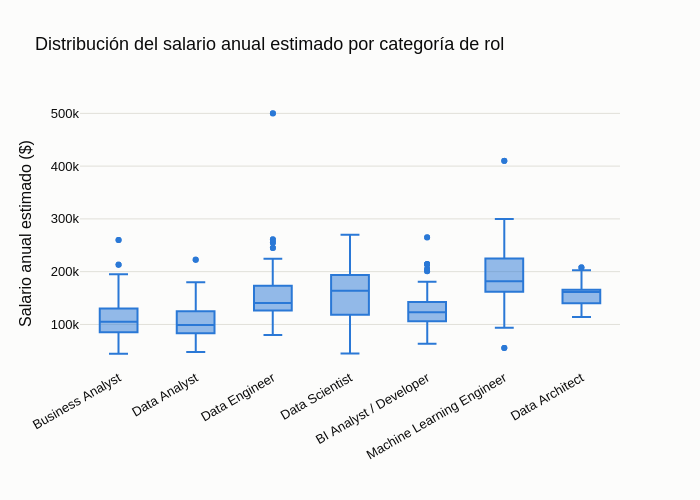

In [22]:
df['salario_estimado_anual'] = df[['salario_min_anual', 'salario_max_anual']].mean(axis=1)

fig = px.box(
    df,
    x='categoria_rol',
    y='salario_estimado_anual',
    category_orders={'categoria_rol': orden_roles},
    title='Distribución del salario anual estimado por categoría de rol',
)

fig.update_traces(marker_color='#2a78d6', line_color='#2a78d6')
fig.update_layout(
    plot_bgcolor='#fcfcfb',
    paper_bgcolor='#fcfcfb',
    xaxis_title='',
    yaxis_title='Salario anual estimado ($)',
    font=dict(color='#0b0b0b', size=13),
)
fig.update_yaxes(gridcolor='#e1e0d9', zeroline=False)
fig.update_xaxes(tickangle=-30)
fig.show()

## 7️⃣ Industrias con más demanda
Identificamos qué sectores de actividad concentran más ofertas de datos y analytics.

In [23]:
df['industrias_lista'].head(10)

,industrias_lista
0,IT Services and IT Consulting
1,IT Services and IT Consulting
2,Financial Services
3,"Motor Vehicle Manufacturing, IT Services and I..."
4,IT Services and IT Consulting
5,IT Services and IT Consulting
6,"Technology, Information and Internet"
7,None
8,"Technology, Information and Internet"
9,Software Development


In [24]:
industrias_expandido = df['industrias_lista'].dropna().str.split(', ').explode()
conteo_industrias = industrias_expandido.value_counts().head(15)
conteo_industrias

,count
industrias_lista,
IT Services and IT Consulting,1270
Financial Services,552
Software Development,532
Technology,252
Hospitals and Health Care,224
Staffing and Recruiting,206
Insurance,186
Information Services,178
Information and Media,154


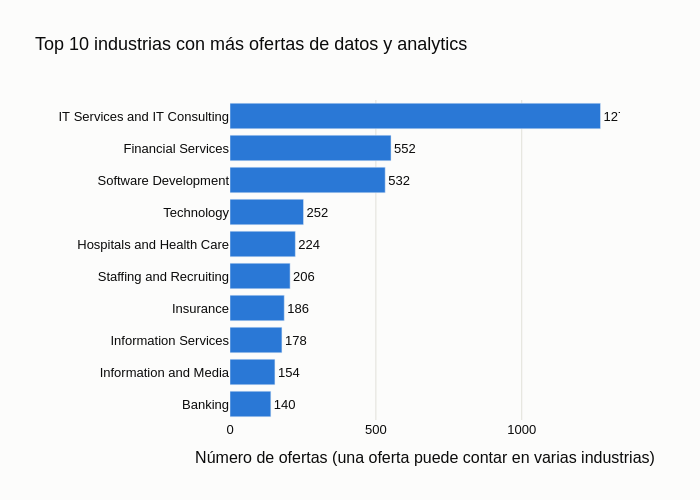

In [25]:
top_industrias = conteo_industrias.head(10).reset_index()
top_industrias.columns = ['industria', 'num_ofertas']

fig = px.bar(
    top_industrias.sort_values('num_ofertas'),
    x='num_ofertas',
    y='industria',
    orientation='h',
    text='num_ofertas',
    title='Top 10 industrias con más ofertas de datos y analytics',
)

fig.update_traces(marker_color='#2a78d6', textposition='outside')
fig.update_layout(
    plot_bgcolor='#fcfcfb',
    paper_bgcolor='#fcfcfb',
    xaxis_title='Número de ofertas (una oferta puede contar en varias industrias)',
    yaxis_title='',
    font=dict(color='#0b0b0b', size=13),
    margin=dict(l=230),
)
fig.update_xaxes(gridcolor='#e1e0d9', zeroline=False)
fig.update_yaxes(showgrid=False)
fig.show()

## 8️⃣ Relación entre vistas y solicitudes
Comprobamos si las ofertas con más visualizaciones reciben también más solicitudes, con un test de correlación de Spearman.

In [26]:
df[['views', 'applies']].describe()

,views,applies
count,4260.000000,2392.000000
mean,47.857746,25.602007
std,105.373059,49.306835
min,1.000000,1.000000
25%,4.000000,2.000000
50%,9.000000,8.000000
75%,43.000000,27.000000
max,1393.000000,566.000000


In [27]:
correlacion = df[['views', 'applies']].corr(method='spearman')
print(correlacion)

            views   applies
views    1.000000  0.929871
applies  0.929871  1.000000


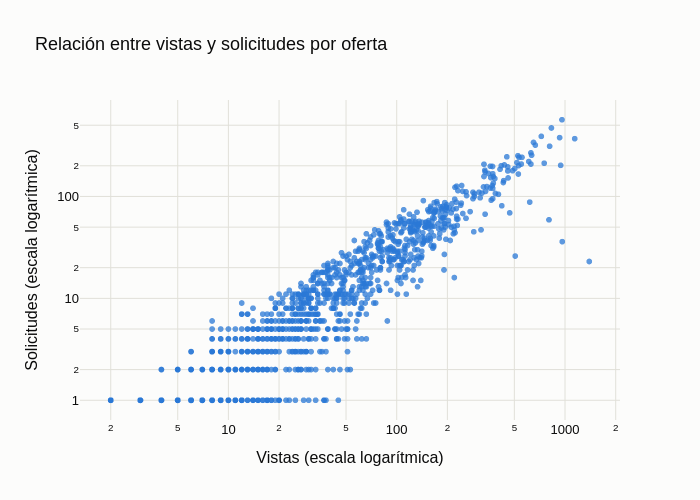

In [28]:
fig = px.scatter(
    df.dropna(subset=['views', 'applies']),
    x='views',
    y='applies',
    title='Relación entre vistas y solicitudes por oferta',
    log_x=True,
    log_y=True,
    opacity=0.5,
)

fig.update_traces(marker=dict(color='#2a78d6', size=6))
fig.update_layout(
    plot_bgcolor='#fcfcfb',
    paper_bgcolor='#fcfcfb',
    xaxis_title='Vistas (escala logarítmica)',
    yaxis_title='Solicitudes (escala logarítmica)',
    font=dict(color='#0b0b0b', size=13),
)
fig.update_xaxes(gridcolor='#e1e0d9', zeroline=False)
fig.update_yaxes(gridcolor='#e1e0d9', zeroline=False)
fig.show()

## 9️⃣ Contraste de hipótesis: diferencias salariales por rol
Aplicamos el test de Mann-Whitney para confirmar con rigor estadístico si las diferencias salariales observadas entre roles son reales.

In [29]:
from scipy.stats import mannwhitneyu

salario_ba = df[df['categoria_rol'] == 'Business Analyst']['salario_estimado_anual'].dropna()
salario_mle = df[df['categoria_rol'] == 'Machine Learning Engineer']['salario_estimado_anual'].dropna()

estadistico, p_valor = mannwhitneyu(salario_ba, salario_mle, alternative='two-sided')

print(f"Business Analyst: n={len(salario_ba)}, mediana={salario_ba.median():.0f}$")
print(f"Machine Learning Engineer: n={len(salario_mle)}, mediana={salario_mle.median():.0f}$")
print(f"Estadístico U = {estadistico:.1f}")
print(f"p-valor = {p_valor:.6f}")

Business Analyst: n=270, mediana=105000$
Machine Learning Engineer: n=98, mediana=182000$
Estadístico U = 2430.0
p-valor = 0.000000


In [30]:
print(f"p-valor = {p_valor:.2e}")

p-valor = 4.91e-33


In [31]:
salario_da = df[df['categoria_rol'] == 'Data Analyst']['salario_estimado_anual'].dropna()

estadistico2, p_valor2 = mannwhitneyu(salario_ba, salario_da, alternative='two-sided')

print(f"Business Analyst: n={len(salario_ba)}, mediana={salario_ba.median():.0f}$")
print(f"Data Analyst: n={len(salario_da)}, mediana={salario_da.median():.0f}$")
print(f"Estadístico U = {estadistico2:.1f}")
print(f"p-valor = {p_valor2:.2e}")

Business Analyst: n=270, mediana=105000$
Data Analyst: n=226, mediana=98800$
Estadístico U = 32486.0
p-valor = 2.14e-01


## 🔟 Profundización: industria x rol y perfil comparativo
Cruzamos industria y rol en términos relativos, y consolidamos una tabla-resumen con las métricas clave de cada categoría.

In [32]:
df_industrias = df[['categoria_rol', 'industrias_lista']].dropna().copy()
df_industrias['industria'] = df_industrias['industrias_lista'].str.split(', ')
df_industrias = df_industrias.explode('industria')

top_10_industrias = conteo_industrias.head(10).index.tolist()
df_industrias_top = df_industrias[df_industrias['industria'].isin(top_10_industrias)]

tabla_industria_rol = pd.crosstab(df_industrias_top['categoria_rol'], df_industrias_top['industria'])
tabla_industria_rol = tabla_industria_rol.reindex(index=orden_roles, columns=top_10_industrias)

tabla_industria_rol

industria,IT Services and IT Consulting,Financial Services,Software Development,Technology,Hospitals and Health Care,Staffing and Recruiting,Insurance,Information Services,Information and Media,Banking
categoria_rol,,,,,,,,,,
Business Analyst,368,140,66,54,56,62,54,48,38,36
Data Analyst,230,76,138,30,46,36,30,34,16,30
Data Engineer,234,136,94,34,40,54,18,28,24,24
Data Scientist,174,118,86,56,30,18,26,20,28,14
BI Analyst / Developer,82,20,52,18,42,16,30,14,16,8
Machine Learning Engineer,54,30,78,44,6,6,6,18,16,4
Data Architect,128,32,18,16,4,14,22,16,16,24


In [33]:
total_por_rol = conteo_roles.set_index('categoria_rol')['num_ofertas']

tabla_industria_rol_pct = tabla_industria_rol.div(total_por_rol, axis=0) * 100
tabla_industria_rol_pct = tabla_industria_rol_pct.round(1)
tabla_industria_rol_pct

industria,IT Services and IT Consulting,Financial Services,Software Development,Technology,Hospitals and Health Care,Staffing and Recruiting,Insurance,Information Services,Information and Media,Banking
categoria_rol,,,,,,,,,,
Business Analyst,33.3,12.7,6.0,4.9,5.1,5.6,4.9,4.3,3.4,3.3
Data Analyst,28.2,9.3,16.9,3.7,5.6,4.4,3.7,4.2,2.0,3.7
Data Engineer,29.5,17.1,11.8,4.3,5.0,6.8,2.3,3.5,3.0,3.0
Data Scientist,24.9,16.9,12.3,8.0,4.3,2.6,3.7,2.9,4.0,2.0
BI Analyst / Developer,21.8,5.3,13.8,4.8,11.2,4.3,8.0,3.7,4.3,2.1
Machine Learning Engineer,20.0,11.1,28.9,16.3,2.2,2.2,2.2,6.7,5.9,1.5
Data Architect,48.1,12.0,6.8,6.0,1.5,5.3,8.3,6.0,6.0,9.0


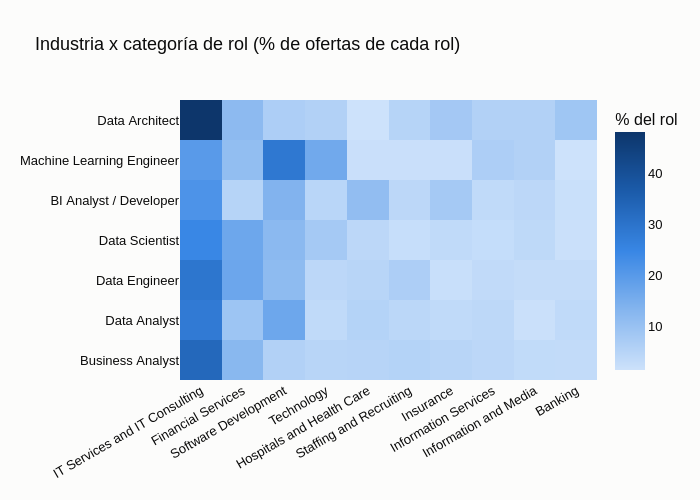

In [34]:
colorscale_azul = [
    [0.0, '#cde2fb'],
    [0.25, '#86b6ef'],
    [0.5, '#3987e5'],
    [0.75, '#1c5cab'],
    [1.0, '#0d366b'],
]

fig = go.Figure(data=go.Heatmap(
    z=tabla_industria_rol_pct.values,
    x=tabla_industria_rol_pct.columns,
    y=tabla_industria_rol_pct.index,
    colorscale=colorscale_azul,
    colorbar=dict(title='% del rol'),
    hovertemplate='%{y} - %{x}: %{z}%<extra></extra>',
))

fig.update_layout(
    title='Industria x categoría de rol (% de ofertas de cada rol)',
    plot_bgcolor='#fcfcfb',
    paper_bgcolor='#fcfcfb',
    font=dict(color='#0b0b0b', size=13),
    margin=dict(l=180, b=120),
)
fig.update_xaxes(tickangle=-30)
fig.show()

In [35]:
resumen_perfil = pd.DataFrame(index=orden_roles)

resumen_perfil['num_ofertas'] = total_por_rol.reindex(orden_roles)

pct_entry = pd.crosstab(df['categoria_rol'], df['formatted_experience_level'], normalize='index')['Entry level'] * 100
resumen_perfil['pct_entry_level'] = pct_entry.reindex(orden_roles).round(1)

resumen_perfil['pct_remoto'] = tabla_remoto['Remoto'].reindex(orden_roles).round(1)

mediana_salario = df.groupby('categoria_rol')['salario_estimado_anual'].median()
resumen_perfil['salario_mediana'] = mediana_salario.reindex(orden_roles).round(0)

industria_principal = tabla_industria_rol_pct.idxmax(axis=1)
pct_industria_principal = tabla_industria_rol_pct.max(axis=1)
resumen_perfil['industria_principal'] = industria_principal.reindex(orden_roles)
resumen_perfil['pct_industria_principal'] = pct_industria_principal.reindex(orden_roles).round(1)

resumen_perfil

,num_ofertas,pct_entry_level,pct_remoto,salario_mediana,industria_principal,pct_industria_principal
Business Analyst,1106,3.8,22.8,105000.0,IT Services and IT Consulting,33.3
Data Analyst,816,28.4,36.5,98800.0,IT Services and IT Consulting,28.2
Data Engineer,794,13.4,30.7,140400.0,IT Services and IT Consulting,29.5
Data Scientist,698,18.9,32.4,163900.0,IT Services and IT Consulting,24.9
BI Analyst / Developer,376,3.2,28.7,123200.0,IT Services and IT Consulting,21.8
Machine Learning Engineer,270,8.1,31.1,182000.0,Software Development,28.9
Data Architect,266,1.5,27.8,161600.0,IT Services and IT Consulting,48.1
